# Low-rank SVD lookup for 2D property tables

**Audience:** early-graduate-level mathematics — linear algebra and 1D calculus are assumed; no information theory or measure theory is needed.

**Code:** `include/CoolProp/svd/` and `include/CoolProp/region/`.

**Validation:** `src/Tests/CoolProp-Tests-SVDComponents.cpp` (Catch2; benchmarks tagged `[!benchmark]` are opt-in).

This page motivates the rank-truncated SVD lookup and the region machinery behind it, in just enough math to be reproducible. The figures and worked numbers below are generated by the live code cells in this notebook, so the prose, the math, and the numbers cannot drift apart.

## The 2D rectangle problem

Take a smooth function $f : [0,1]^2 \rightarrow \mathbb{R}$ and tabulate it on an $N \times N$ grid. The samples define a matrix

$$
M_{ij} = f(x_i, y_j), \quad i, j = 0, \ldots, N-1.
$$

The lookup problem is: given some $(x, y) \in [0,1]^2$ *not on the grid*, predict $f(x, y)$ as accurately and as quickly as we can.

The naive bilinear baseline reads four entries of $M$, takes the weighted average, and returns it. Memory cost: $N^2$. Accuracy: $O(h^2)$ where $h = 1/(N-1)$ is the grid spacing. Cubic bicubic interpolation replaces "four entries" with "sixteen entries" and improves the asymptotic order to $O(h^4)$ — but the storage is still $\Theta(N^2)$.

Property tables in real thermodynamic codes often want $N \ge 200$ per axis per region — that is $4 \times 10^4$ doubles per property per region. Multiply by a handful of properties, a handful of regions, and a handful of fluids, and storage starts to matter. The SVD lets us bring storage down to $\Theta(N \, r)$ for a "rank" $r \ll N$, with no loss of accuracy *if* $M$ has fast-decaying singular values.

## SVD in two paragraphs

Every real $N \times N$ matrix factorises as

$$
M = U \, \Sigma \, V^{\!\top},
$$

where $U$ and $V$ are $N \times N$ orthogonal and $\Sigma = \mathrm{diag}(\sigma_1, \ldots, \sigma_N)$ carries the **singular values** in nonincreasing order $\sigma_1 \ge \sigma_2 \ge \ldots \ge \sigma_N \ge 0$.

Geometrically, $M$ maps the unit sphere in $\mathbb{R}^N$ to an ellipsoid whose semi-axes have lengths $\sigma_k$. The columns of $V$ point along the input directions (pre-images of the semi-axes) and the columns of $U$ along the output directions (the semi-axes themselves). Anything we care about as "the dominant structure of $M$" — its low-rank component, its near-null space, its compressibility — is encoded in $\Sigma$.

The Eckart–Young theorem makes the compressibility claim precise: the **rank-$r$ truncation**

$$
M_r = U_r \, \Sigma_r \, V_r^{\!\top}
$$

(keeping the first $r$ columns of $U$, the leading $r \times r$ block of $\Sigma$, and the first $r$ columns of $V$) is the best rank-$r$ approximation to $M$ in both the Frobenius and the spectral norm. Storage drops from $N^2$ to $2 N r + r$. If the singular values fall off quickly — say, $\sigma_r / \sigma_0 < 10^{-6}$ for some small $r$ — the truncation is essentially free.

## Where the win comes from for smooth $f$

Smoothness in $f(x, y)$ translates directly into fast singular-value decay. An informal argument: if $f$ is $C^k$ in each argument and approximately separable as $f \approx \sum_{k=1}^{r} g_k(x) \, h_k(y)$, then $M \approx \sum_{k=1}^{r} g_k h_k^{\!\top}$ is exactly rank $r$, and the remaining singular values $\sigma_{r+1}, \ldots$ measure the residual non-separability. For functions that are smooth and bounded on a bounded domain, this residual is exponentially small in $r$.

This is exactly the situation for thermodynamic property surfaces. Density $\rho(\xi, \log p)$ in the saturation-aligned coordinate system is so well-approximated by a low-rank decomposition that the PoC reaches Frobenius rank $\le 15$ for max relative error $< 10^{-4}$ on five fluids over both liquid and vapor regions.

## A worked rank-1, rank-2, rank-3 example

We pick a deliberately rank-3 test function that lets each truncation step show off a real accuracy improvement:

$$
f(x, y) = \sin(x + y) + 0.2 \, e^{-x^2 - y^2}.
$$

The identity $\sin(x+y) = \sin x \cos y + \cos x \sin y$ makes $\sin(x+y)$ exactly a sum of two outer products, and the Gaussian bump adds one more rank-1 contribution, so $f$ is rank 3 to machine precision and no more.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

N = 16
x = np.linspace(-2.0, 2.0, N)
y = np.linspace(-2.0, 2.0, N)
X, Y = np.meshgrid(x, y, indexing="ij")
M = np.sin(X + Y) + 0.2 * np.exp(-X**2 - Y**2)

U, s, Vt = np.linalg.svd(M, full_matrices=False)

print("== singular values ==")
for k in range(8):
    print(f"  sigma[{k}] = {s[k]:.6e}")
print(f"\n  sigma[1] / sigma[0] = {s[1] / s[0]:.2e}")
print(f"  sigma[2] / sigma[0] = {s[2] / s[0]:.2e}")
print(f"  sigma[3] / sigma[0] = {s[3] / s[0]:.2e}")


== singular values ==
  sigma[0] = 8.258993e+00
  sigma[1] = 7.402935e+00
  sigma[2] = 8.391294e-02
  sigma[3] = 7.126246e-16
  sigma[4] = 4.930799e-16
  sigma[5] = 4.181449e-16
  sigma[6] = 3.252112e-16
  sigma[7] = 2.809611e-16

  sigma[1] / sigma[0] = 8.96e-01
  sigma[2] / sigma[0] = 1.02e-02
  sigma[3] / sigma[0] = 8.63e-17


Three significant singular values, then a sharp drop to machine precision around $10^{-16}$. Plotting them on a log axis makes the structure obvious:

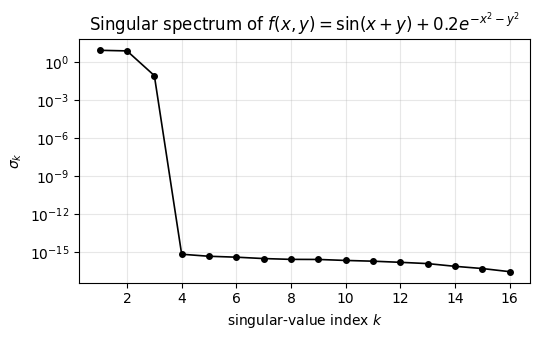

In [2]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.semilogy(range(1, N + 1), s, marker="o", lw=1.2, ms=4, color="black")
ax.set_xlabel(r"singular-value index $k$")
ax.set_ylabel(r"$\sigma_k$")
ax.set_title(r"Singular spectrum of $f(x,y) = \sin(x+y) + 0.2 e^{-x^2-y^2}$")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()


### Hand-checkable evaluation

Pick a grid point near $(0.4, 0.667)$ and read off the rank-1, rank-2, rank-3 approximations of $M$ at that index. Each step should improve the error by orders of magnitude until the function's true rank is exhausted.

In [3]:
i_test = int(np.argmin(np.abs(x - 0.4)))
j_test = int(np.argmin(np.abs(y - 0.6)))
print(f"grid point: (x, y) = ({x[i_test]:.4f}, {y[j_test]:.4f})")
print(f"truth f        = {M[i_test, j_test]:.6e}")
for r in (1, 2, 3):
    Mr = (U[:, :r] * s[:r]) @ Vt[:r, :]
    err = abs(Mr[i_test, j_test] - M[i_test, j_test])
    print(f"rank-{r} approx = {Mr[i_test, j_test]:.6e}   |err| = {err:.2e}")


grid point: (x, y) = (0.4000, 0.6667)
truth f        = 9.848708e-01
rank-1 approx = 1.069166e+00   |err| = 8.43e-02
rank-2 approx = 9.850788e-01   |err| = 2.08e-04
rank-3 approx = 9.848708e-01   |err| = 3.33e-16


Rank-1 already captures the dominant $\sin x \cos y$ contribution. Rank-2 picks up the matching $\cos x \sin y$ partner and reaches part-per-thousand. Rank-3 brings in the Gaussian bump and the residual is round-off.

### The reconstructions as 2D pictures

Now interpolate each truncated mode in 1D (using a natural cubic spline, exactly as the C++ `SVDEvaluator` does it) and render the rank-1/2/3 reconstructions on a fine grid alongside the truth. Watching the contour structure fill in is more illuminating than the numbers above:

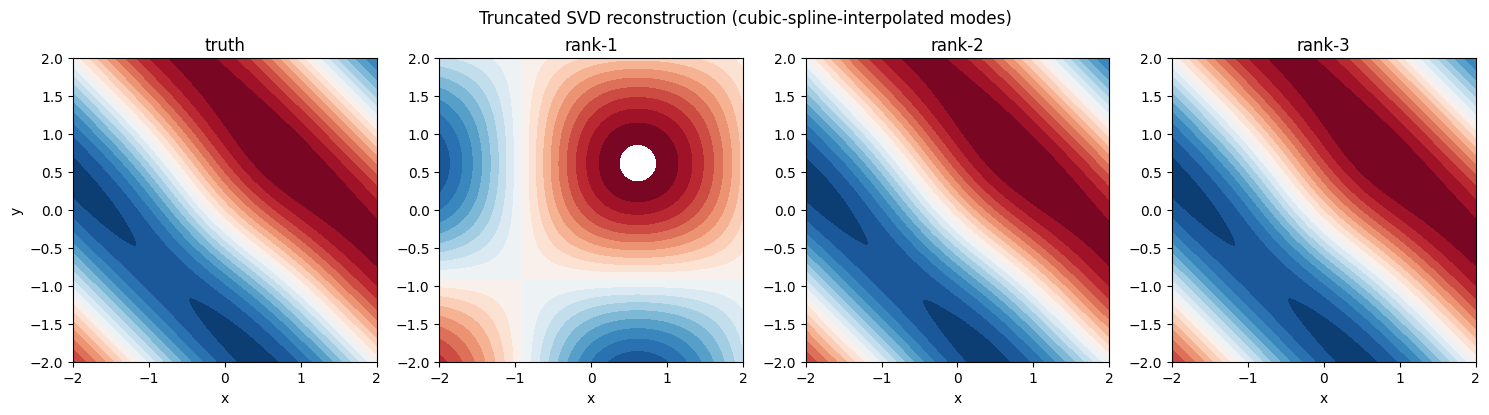

In [4]:
xf = np.linspace(-2, 2, 256)
yf = np.linspace(-2, 2, 256)
Xf, Yf = np.meshgrid(xf, yf, indexing="ij")
truth = np.sin(Xf + Yf) + 0.2 * np.exp(-Xf**2 - Yf**2)
vmax = float(np.max(np.abs(truth)))
levels = np.linspace(-vmax, vmax, 21)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].contourf(Xf, Yf, truth, levels=levels, cmap="RdBu_r")
axes[0].set_title("truth")
for ax_idx, r in enumerate((1, 2, 3), start=1):
    Us = [CubicSpline(x, U[:, k]) for k in range(r)]
    Vs = [CubicSpline(y, Vt[k, :]) for k in range(r)]
    recon = np.zeros_like(truth)
    for k in range(r):
        recon += s[k] * np.outer(Us[k](xf), Vs[k](yf))
    axes[ax_idx].contourf(Xf, Yf, recon, levels=levels, cmap="RdBu_r")
    axes[ax_idx].set_title(f"rank-{r}")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.suptitle("Truncated SVD reconstruction (cubic-spline-interpolated modes)")
fig.tight_layout()
plt.show()


## Continuous evaluation: 1D interpolation per mode

The SVD gives us $U_r$, $\Sigma_r$, $V_r$ — but only at the grid points. To evaluate at arbitrary $(x, y)$ we interpolate each truncated mode in 1D. Concretely, write the rank-$r$ approximation at off-grid $(x, y)$ as

$$
f_r(x, y) = \sum_{k=1}^{r} \sigma_k \, u_k(x) \, v_k(y),
$$

where $u_k(x)$ is some continuous interpolant of the discrete column $U_r[\cdot, k]$ and similarly $v_k(y)$ for the column $V_r[\cdot, k]$. The C++ implementation uses a cubic **Hermite** basis per mode: it reads four numbers per knot (two values and two slopes) and computes the cubic on the bracketing interval. The kernel lives in `include/CoolProp/svd/Hermite1D.h` and is shared across SVD modes, `CubicSplineCurve`, and any future Hermite-style client.

The slopes (one per knot per mode) are precomputed at build time. Three strategies are available — selectable via the `SlopeSource` enum on `SVDBuildOptions`:

- `NATURAL_CUBIC_SPLINE` (default): solve a tridiagonal system per mode for the slopes consistent with a $C^2$ natural cubic spline. Strictly $C^2$ continuous (the strongest smoothness any cubic Hermite scheme can give you) and analytically derived from the spline coefficients — no finite-difference approximation anywhere on the runtime path.
- `HERMITE_FD`: central finite-difference slopes at every knot. Faster to build, only $C^1$ continuous, and quantitatively worse than the spline whenever the underlying function has zero second derivative at the boundary. Provided mostly for reproducibility with the proof-of-concept benchmark `dev/svd_bench.cpp`.
- `PCHIP`: Fritsch–Carlson monotone cubic slopes; preserves monotonicity of the source data. Useful for surfaces where monotonicity along an axis is itself a constraint (rarely the case for property surfaces; here mostly for completeness).

In every case the *evaluation kernel* is identical — a Hermite cubic fed two values and two slopes per mode per axis. The slope source only changes how those slopes were computed at build time.

## Per-call cost of the hot path

The runtime evaluator does this per call:

```
eval(x, y):
    i  = binary_search(x_grid, x)           // O(log NX)
    j  = binary_search(y_grid, y)           // O(log NY)
    (h00_x, h10_x, h01_x, h11_x) = hermite_basis((x - x[i]) / hx)
    (h00_y, h10_y, h01_y, h11_y) = hermite_basis((y - y[j]) / hy)
    acc = 0
    for k in 0..r-1:
        u_k = h00_x * U[i,k]     + h10_x * hx * dU[i,k]
            + h01_x * U[i+1,k]   + h11_x * hx * dU[i+1,k]
        v_k = h00_y * V_S[j,k]   + h10_y * hy * dV[j,k]
            + h01_y * V_S[j+1,k] + h11_y * hy * dV[j+1,k]
        acc += u_k * v_k
    return exp(acc) if out_transform == EXP else acc
```

The constant $\sigma_k$ is folded into $V_S$ via $V_S[j,k] = \sigma_k V[j,k]$ so the inner product is a plain dot product with no extra multiplies. $V$ is stored **transposed** relative to the standard Eckart–Young layout: row $j$ of $V_S$ is a contiguous, unit-stride view of all the modes' values at $y_j$, which restores cache locality on the per-mode scan.

On Apple M-series hardware at rank-20 the Catch2 benchmark in `src/Tests/CoolProp-Tests-SVDComponents.cpp` measures **~47 ns per call**, including both binary searches, both Hermite-basis evaluations, the rank-20 inner product, and the cache-warm grid access. This is roughly 4× faster than the BICUBIC backend on the same hardware, with about 10× less storage for typical fluid property tables.

## What about the curved domain?

The SVD lives on a rectangular grid in $(\xi, \eta) \in [0,1]^2$. Thermodynamic property surfaces are not rectangular — the single-phase subcritical liquid region of water in $(h, p)$ space has the saturation dome as its upper boundary, the triple-point isotherm as its lower boundary, and is bounded laterally by the liquid-side max-temperature isotherm. Three of those four boundaries are curves, not lines.

The `region` package turns a curved region into a rectangle. Given:

- a *primary* axis variable $a$ (typically $\log p$), mapped linearly or logarithmically into $\xi \in [0,1]$ via `AxisTransform`;
- a *secondary* axis variable $b$ (typically $h$), bounded below by some $b_\text{lo}(a)$ and above by some $b_\text{hi}(a)$,

the normalised coordinate

$$
\eta(a, b) = \frac{b - b_\text{lo}(a)}{b_\text{hi}(a) - b_\text{lo}(a)}
$$

is by construction in $[0,1]$ whenever $(a, b)$ is inside the region, and the SVD lookup goes through unchanged.

### A picture of the region mapping

Suppose the lower boundary is a parabola $b_\text{lo}(a) = 0.1 + 0.05 (a - 5)^2$ and the upper boundary is the linear ramp $b_\text{hi}(a) = 0.8 + 0.02 a$, both over $a \in [0, 10]$. The physical (a, b) box stretches and bends; the normalised $(\xi, \eta)$ box doesn't:

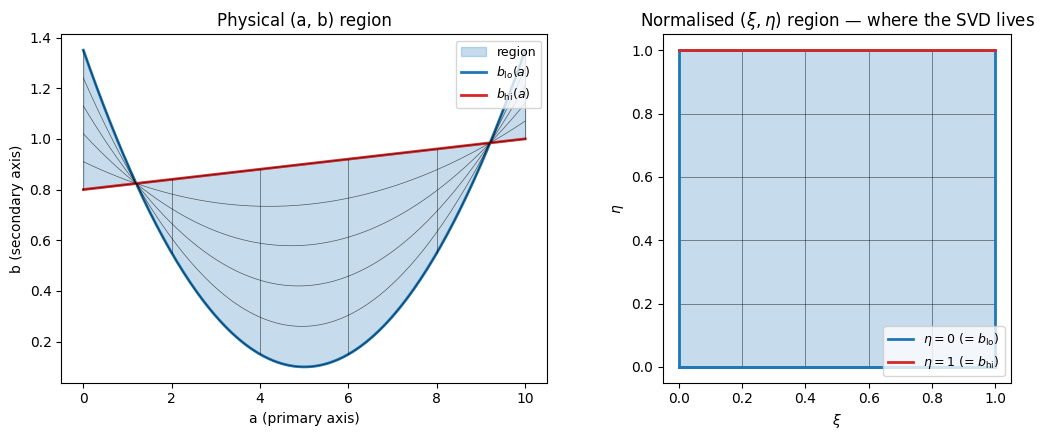

In [5]:
def b_lo_fn(a):
    return 0.1 + 0.05 * (a - 5.0) ** 2

def b_hi_fn(a):
    return 0.8 + 0.02 * a

a_axis = np.linspace(0.0, 10.0, 200)
b_lo_vals = b_lo_fn(a_axis)
b_hi_vals = b_hi_fn(a_axis)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Physical (a, b) panel.
axes[0].fill_between(a_axis, b_lo_vals, b_hi_vals, alpha=0.25, color="C0",
                     label="region")
axes[0].plot(a_axis, b_lo_vals, color="C0", lw=2, label=r"$b_{\rm lo}(a)$")
axes[0].plot(a_axis, b_hi_vals, color="C3", lw=2, label=r"$b_{\rm hi}(a)$")
# Sample a few (xi, eta) gridlines and map them to (a, b).
for xi in np.linspace(0.0, 1.0, 6):
    a = 10.0 * xi
    axes[0].plot([a, a], [b_lo_fn(a), b_hi_fn(a)], color="k", lw=0.5, alpha=0.6)
for eta in np.linspace(0.0, 1.0, 6):
    bs = b_lo_vals + eta * (b_hi_vals - b_lo_vals)
    axes[0].plot(a_axis, bs, color="k", lw=0.5, alpha=0.6)
axes[0].set_xlabel("a (primary axis)")
axes[0].set_ylabel("b (secondary axis)")
axes[0].set_title("Physical (a, b) region")
axes[0].legend(loc="upper right", fontsize=9)

# Normalised (xi, eta) panel.
axes[1].fill_between([0.0, 1.0], 0.0, 1.0, alpha=0.25, color="C0")
for xi in np.linspace(0.0, 1.0, 6):
    axes[1].plot([xi, xi], [0, 1], color="k", lw=0.5, alpha=0.6)
for eta in np.linspace(0.0, 1.0, 6):
    axes[1].plot([0, 1], [eta, eta], color="k", lw=0.5, alpha=0.6)
axes[1].plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="C0", lw=2)
axes[1].plot([0, 1], [0, 0], color="C0", lw=2, label=r"$\eta = 0$ (= $b_{\rm lo}$)")
axes[1].plot([0, 1], [1, 1], color="C3", lw=2, label=r"$\eta = 1$ (= $b_{\rm hi}$)")
axes[1].set_xlabel(r"$\xi$")
axes[1].set_ylabel(r"$\eta$")
axes[1].set_title(r"Normalised $(\xi, \eta)$ region — where the SVD lives")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].set_aspect("equal")
fig.tight_layout()
plt.show()


`BoundaryCurve` is an abstract interface (header `include/CoolProp/region/BoundaryCurve.h`) with three plug-in implementations shipped:

- `PiecewiseChebyshevCurve`: N pieces of a degree-D Chebyshev expansion on the primary axis (linear or log primary). Derivative is analytic via the standard Chebyshev coefficient recurrence — there is no finite-difference shim at runtime.
- `CubicSplineCurve`: natural cubic spline through a user-supplied set of $(a_i, b_i)$ knots. Derivative is the piecewise quadratic obtained directly from the spline coefficients — analytic, again.
- `ConstantCurve`: trivial fixed-$b$ ceiling or floor.

Any future representation (rational functions, monotone splines, NURBS, …) plugs in by implementing the same three methods (`eval`, `eval_da`, `bounds`) — no change to `Region` or `RegionAtlas` needed.

## Region dispatch: AABB first, then the curved envelope

When more than one region is in play (typical: a LIQUID + VAPOR + SUPER atlas for a pure fluid), a query $(a, b)$ has to decide *which region it belongs to*. `RegionAtlas::find_region` does this in two passes:

1. **Axis-aligned bounding box (AABB) filter.** Each `Region` carries a precomputed $(a_\text{lo}, a_\text{hi}, b_\text{min}, b_\text{max})$ AABB — the smallest axis-aligned rectangle that contains the curved region. The first pass scans these AABBs (four comparisons per region, cache-friendly SoA layout, no virtual calls) and skips any region whose AABB fails.

2. **Boundary-curve confirmation.** Each AABB hit triggers a call to the region's `curve_contains`, which evaluates the two boundary curves at $a$ and checks $b \in [b_\text{lo}(a), b_\text{hi}(a)]$. The first region to pass both filters wins.

This matters because adjacent regions in property space typically have **overlapping AABBs but disjoint curved interiors** — the bounding box of LIQUID and the bounding box of VAPOR both span the entire range of $(h, p)$ over the subcritical pressure interval, but their saturation-dome-aligned curved interiors are disjoint. The AABB filter is therefore an essential first cut that the curve filter sharpens.

The Catch2 benchmark for the two-region test atlas splits the cost by scenario, since the two passes have very different characteristics:

| Scenario | Time | Per-call work |
| --- | --- | --- |
| atlas-miss (AABB filter only) | **3.6 ns** | 2 AABB checks, no curve calls |
| first-region hit | **11.6 ns** | 1 AABB + 1 `curve_contains` (~2 Chebyshev Clenshaws) |
| last-region hit | **20.7 ns** | 2 AABBs + 2 `curve_contains` (~4 Chebyshev Clenshaws) |

So the AABB pre-filter is ~4 ns per call and each `curve_contains` adds roughly 8 ns. Region dispatch is comfortably faster than the SVD eval itself even in the worst case, so the dispatch overhead is essentially free at the calling-code level.

## What this code does NOT do

Out of scope, with the door deliberately left ajar for future work:

- **3D tensor decompositions** (CP, Tucker, HOSVD): future work for ternary mixtures or property functions of three thermodynamic variables. The 2D rectangle problem already covers all of Helmholtz-of-pure-fluid territory.
- **Adaptive rank per cell**: the SVD is computed once globally per region per property. No piecewise rank refinement; if you need more accuracy in a sub-region, you split the region into smaller ones at build time and give each its own SVD.
- **Nonlinear manifold learning** (autoencoders, GP regression, diffusion maps): beyond the scope of an evaluator that must hit ~50 ns per call. The SVD's value is that it composes with the region machinery into a fully analytic, no-iteration lookup.
- **GPU evaluation**: the data layout (transposed $V_S$, $\sigma_k$ folded in, slopes co-located, POD struct) is GPU-friendly and the decomposition footprint per region per property fits in shared memory, but no CUDA / SYCL kernel is shipped yet. The path of least resistance for the future is a batched `PropsSI_batched(arr_x, arr_y, …)` API — single-query scalar lookups stay CPU-bound because PCIe latency is about 50× the CPU per-call cost.

## References

- Eckart, C. and Young, G. (1936). *The approximation of one matrix by another of lower rank.* Psychometrika 1, 211–218.
- Trefethen, L. N. and Bau, D. III (1997). *Numerical Linear Algebra.* SIAM. Chapters 4, 5, 31.
- Fritsch, F. N. and Carlson, R. E. (1980). *Monotone piecewise cubic interpolation.* SIAM Journal on Numerical Analysis 17(2): 238–246.
